In [2]:
!unzip -q /content/*.zip -d /content/dms_raw
print("Extraction complete!")

Extraction complete!


In [3]:
import os
import glob
import yaml
import shutil

print("--- Starting Processing Pipeline ---")

# 1. SETUP FINAL FOLDERS
output_base = '/content/dms_processed_yolo'
splits = ['train', 'valid', 'test']

# Cleaning up any old runs
if os.path.exists(output_base):
    shutil.rmtree(output_base)

for split in splits:
    os.makedirs(os.path.join(output_base, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_base, split, 'labels'), exist_ok=True)

# 2. FILTER & REMAP CLASSES
# Adjust '3' and '4' if your original dataset uses different IDs for Phone and Seatbelt
CLASS_MAP = {'3': '0', '4': '1'}
stats = {'Phone': 0, 'Seatbelt': 0, 'Total_Images': 0}

for split in splits:
    raw_img_dir = os.path.join('/content/dms_raw', split, 'images')
    raw_lbl_dir = os.path.join('/content/dms_raw', split, 'labels')

    # Handle naming variations (sometimes 'valid' is called 'val')
    if not os.path.exists(raw_img_dir) and split == 'valid':
        raw_img_dir = os.path.join('/content/dms_raw', 'val', 'images')
        raw_lbl_dir = os.path.join('/content/dms_raw', 'val', 'labels')

    if not os.path.exists(raw_img_dir):
        continue

    # Find all images
    image_paths = glob.glob(os.path.join(raw_img_dir, '*.jpg')) + \
                  glob.glob(os.path.join(raw_img_dir, '*.png'))

    for img_path in image_paths:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        txt_path = os.path.join(raw_lbl_dir, f"{base_name}.txt")

        if not os.path.exists(txt_path):
            continue

        with open(txt_path, 'r') as f:
            lines = f.readlines()

        valid_lines = []
        for line in lines:
            parts = line.strip().split()
            if not parts: continue

            class_id = parts[0]
            if class_id in CLASS_MAP:
                # Basic quality check: ensure coordinates are valid YOLO format (0 to 1)
                coords = [float(x) for x in parts[1:]]
                if any(c < 0.0 or c > 1.0 for c in coords):
                    continue

                parts[0] = CLASS_MAP[class_id]
                valid_lines.append(" ".join(parts) + "\n")

                if parts[0] == '0': stats['Phone'] += 1
                if parts[0] == '1': stats['Seatbelt'] += 1

        # If we kept at least one valid box, copy the image and new label over
        if valid_lines:
            stats['Total_Images'] += 1
            shutil.copy(img_path, os.path.join(output_base, split, 'images', os.path.basename(img_path)))

            with open(os.path.join(output_base, split, 'labels', f"{base_name}.txt"), 'w') as f:
                f.writelines(valid_lines)

print(f"\n--- Metrics ---")
print(f"Total Filtered Images Saved: {stats['Total_Images']}")
print(f"Total Phone Boxes: {stats['Phone']}")
print(f"Total Seatbelt Boxes: {stats['Seatbelt']}")

# 3. CREATE DATA.YAML
yaml_data = {
    'train': '../train/images',
    'val': '../valid/images',
    'test': '../test/images',
    'nc': 2,
    'names': ['Phone', 'Seatbelt']
}

with open(os.path.join(output_base, 'data.yaml'), 'w') as f:
    yaml.dump(yaml_data, f, sort_keys=False)

# 4. ZIPPING FINAL FOLDER FOR DOWNLOAD
archive_path = '/content/Sohini_Processed_Dataset'
shutil.make_archive(archive_path, 'zip', output_base)

print(f"\n--- SUCCESS! ---")
print(f"Clean dataset is ready. Please download 'Sohini_Processed_Dataset.zip'.")

--- Starting Processing Pipeline ---

--- Metrics ---
Total Filtered Images Saved: 6140
Total Phone Boxes: 2552
Total Seatbelt Boxes: 4149

--- SUCCESS! ---
Clean dataset is ready. Please download 'Sohini_Processed_Dataset.zip'.


--- Generating Fundamental Object Detection EDA ---


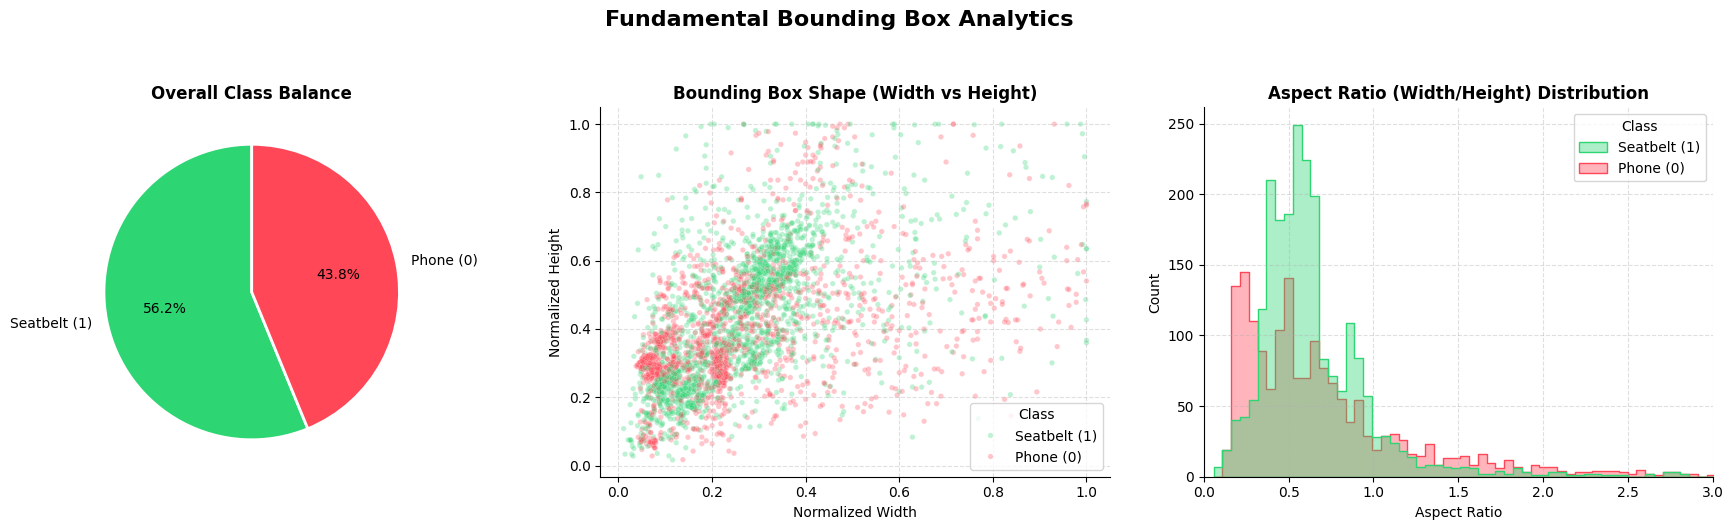

Saved: /content/basic_yolo_eda.png


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths based on your processed dataset
train_labels_dir = '/content/dms_processed_yolo/train/labels'

print("--- Generating Fundamental Object Detection EDA ---")

# 1. Gather the basic dimensional data
data = []
valid_files = [f for f in os.listdir(train_labels_dir) if f.endswith('.txt')]

for txt_file in valid_files:
    with open(os.path.join(train_labels_dir, txt_file), 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, x, y, w, h = map(float, parts)

                class_name = 'Phone (0)' if class_id == 0.0 else 'Seatbelt (1)'
                aspect_ratio = w / h if h > 0 else 0

                data.append({
                    'Class': class_name,
                    'Width': w,
                    'Height': h,
                    'Aspect_Ratio': aspect_ratio
                })

df = pd.DataFrame(data)

if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Fundamental Bounding Box Analytics', fontsize=16, fontweight='bold', y=1.05)

    # Plot 1: Overall Class Balance (Pie Chart)
    class_counts = df['Class'].value_counts()
    axes[0].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
                colors=['#2ed573', '#ff4757'], startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[0].set_title('Overall Class Balance', fontweight='bold')

    # Plot 2: Width vs Height Scatter (Shape Analysis)
    sns.scatterplot(data=df, x='Width', y='Height', hue='Class',
                    palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                    alpha=0.3, s=15, ax=axes[1])
    axes[1].set_title('Bounding Box Shape (Width vs Height)', fontweight='bold')
    axes[1].set_xlabel('Normalized Width')
    axes[1].set_ylabel('Normalized Height')
    axes[1].grid(linestyle='--', alpha=0.4)

    # Plot 3: Aspect Ratio Distribution
    sns.histplot(data=df, x='Aspect_Ratio', hue='Class', element="step",
                 palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                 ax=axes[2], common_norm=False, alpha=0.4)
    axes[2].set_title('Aspect Ratio (Width/Height) Distribution', fontweight='bold')
    axes[2].set_xlabel('Aspect Ratio')
    axes[2].set_ylabel('Count')
    axes[2].set_xlim(0, 3)
    axes[2].grid(linestyle='--', alpha=0.4)

    sns.despine(ax=axes[1])
    sns.despine(ax=axes[2])
    plt.tight_layout()

    basic_chart_path = '/content/basic_yolo_eda.png'
    plt.savefig(basic_chart_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {basic_chart_path}")
else:
    print("No bounding box data found to plot.")

--- Generating Advanced Spatial EDA ---


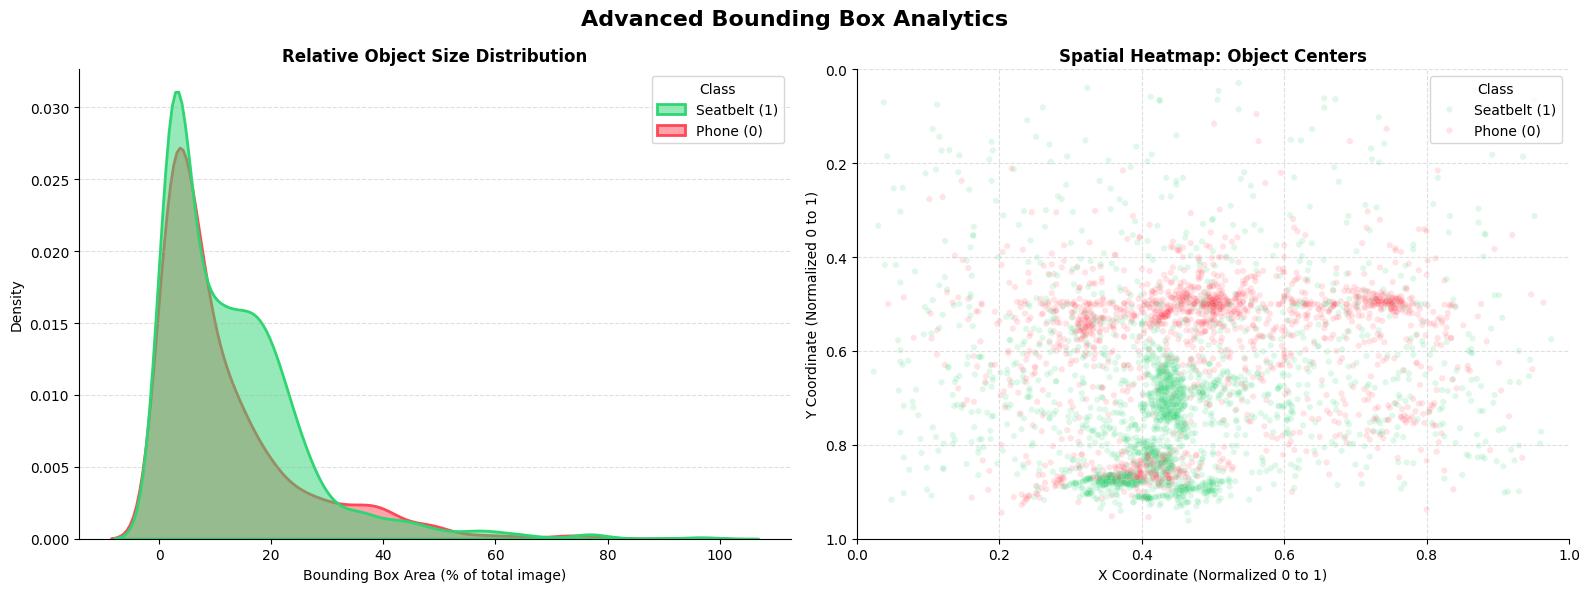

Saved: /content/advanced_spatial_eda.png


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_labels_dir = '/content/dms_processed_yolo/train/labels'

print("--- Generating Advanced Spatial EDA ---")

# 1. Parse all labels into a DataFrame
data = []
valid_files = [f for f in os.listdir(train_labels_dir) if f.endswith('.txt')]

for txt_file in valid_files:
    with open(os.path.join(train_labels_dir, txt_file), 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, x, y, w, h = map(float, parts)

                # YOLO format gives normalized width and height. Area = w * h
                area = (w * h) * 100
                class_name = 'Phone (0)' if class_id == 0.0 else 'Seatbelt (1)'

                data.append({
                    'Class': class_name,
                    'X_Center': x,
                    'Y_Center': y,
                    'Area_Percent': area
                })

df = pd.DataFrame(data)

if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Advanced Bounding Box Analytics', fontsize=16, fontweight='bold')

    # Plot 1: Object Size (Area) Distribution
    sns.kdeplot(data=df, x='Area_Percent', hue='Class', fill=True,
                palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                ax=axes[0], alpha=0.5, linewidth=2)

    axes[0].set_title('Relative Object Size Distribution', fontweight='bold')
    axes[0].set_xlabel('Bounding Box Area (% of total image)')
    axes[0].set_ylabel('Density')
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    # Plot 2: Spatial Distribution Heatmap
    sns.scatterplot(data=df, x='X_Center', y='Y_Center', hue='Class',
                    palette={'Phone (0)': '#ff4757', 'Seatbelt (1)': '#2ed573'},
                    alpha=0.15, s=20, ax=axes[1])

    axes[1].set_title('Spatial Heatmap: Object Centers', fontweight='bold')
    axes[1].set_xlabel('X Coordinate (Normalized 0 to 1)')
    axes[1].set_ylabel('Y Coordinate (Normalized 0 to 1)')

    # Invert Y-axis so the plot matches how images are rendered (0,0 at top left)
    axes[1].invert_yaxis()
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(1, 0)
    axes[1].grid(linestyle='--', alpha=0.4)

    sns.despine()
    plt.tight_layout()

    adv_chart_path = '/content/advanced_spatial_eda.png'
    plt.savefig(adv_chart_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {adv_chart_path}")
else:
    print("No bounding box data found to plot.")

In [6]:
import os
import glob

dataset_dir = '/content/dms_processed_yolo'
splits = ['train', 'valid', 'test']

print("==================================================")
print(" 1. CLASS MAPPING & DOCUMENTATION")
print("==================================================")
print("Target classes tracked explicitly via YOLO bounding boxes:")
print(" - Class 0: 'Phone' (Covers: phone, phone usage, mobile near driver)")
print(" - Class 1: 'Seatbelt' (Covers: seat belt, person with seat belt)")
print("\nNegative states handled implicitly (Absence of bounding box):")
print(" - 'no seat belt' / 'person without seat belt'")
print(" - 'no phone usage'")
print("==================================================\n")

print("==================================================")
print(" 2. DATASET SIZE & METRICS CHECK")
print("==================================================")

total_images = 0
total_labels = 0
class_counts = {'0 (Phone)': 0, '1 (Seatbelt)': 0}

for split in splits:
    img_dir = os.path.join(dataset_dir, split, 'images')
    lbl_dir = os.path.join(dataset_dir, split, 'labels')

    # Handle 'val' naming variation
    if not os.path.exists(img_dir) and split == 'valid':
        img_dir = os.path.join(dataset_dir, 'val', 'images')
        lbl_dir = os.path.join(dataset_dir, 'val', 'labels')

    if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
        print(f"Skipping {split} - Directory not found.")
        continue

    # Count Images
    images = glob.glob(os.path.join(img_dir, '*.jpg')) + glob.glob(os.path.join(img_dir, '*.png'))
    split_img_count = len(images)
    total_images += split_img_count

    # Count Labels
    labels = glob.glob(os.path.join(lbl_dir, '*.txt'))
    split_lbl_count = len(labels)
    total_labels += split_lbl_count

    # Count Bounding Boxes
    for txt_file in labels:
        with open(txt_file, 'r') as f:
            for line in f:
                class_id = line.strip().split()[0]
                if class_id == '0':
                    class_counts['0 (Phone)'] += 1
                elif class_id == '1':
                    class_counts['1 (Seatbelt)'] += 1

    print(f"[{split.upper()} SPLIT]")
    print(f"  - Images: {split_img_count}")
    print(f"  - Label Files: {split_lbl_count}")

print("\n[TOTAL DATASET METRICS]")
print(f"  - Total Images: {total_images}")
print(f"  - Total Label Files: {total_labels}")
print(f"  - Total 'Phone' Bounding Boxes: {class_counts['0 (Phone)']}")
print(f"  - Total 'Seatbelt' Bounding Boxes: {class_counts['1 (Seatbelt)']}")
print("==================================================")

 1. CLASS MAPPING & DOCUMENTATION
Target classes tracked explicitly via YOLO bounding boxes:
 - Class 0: 'Phone' (Covers: phone, phone usage, mobile near driver)
 - Class 1: 'Seatbelt' (Covers: seat belt, person with seat belt)

Negative states handled implicitly (Absence of bounding box):
 - 'no seat belt' / 'person without seat belt'
 - 'no phone usage'

 2. DATASET SIZE & METRICS CHECK
[TRAIN SPLIT]
  - Images: 3534
  - Label Files: 3534
[VALID SPLIT]
  - Images: 1959
  - Label Files: 1959
[TEST SPLIT]
  - Images: 647
  - Label Files: 647

[TOTAL DATASET METRICS]
  - Total Images: 6140
  - Total Label Files: 6140
  - Total 'Phone' Bounding Boxes: 2552
  - Total 'Seatbelt' Bounding Boxes: 4149


--- Visual Quality Check: Inspecting Processed Annotations ---


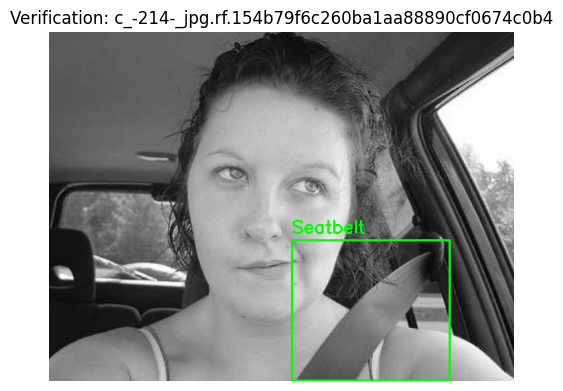

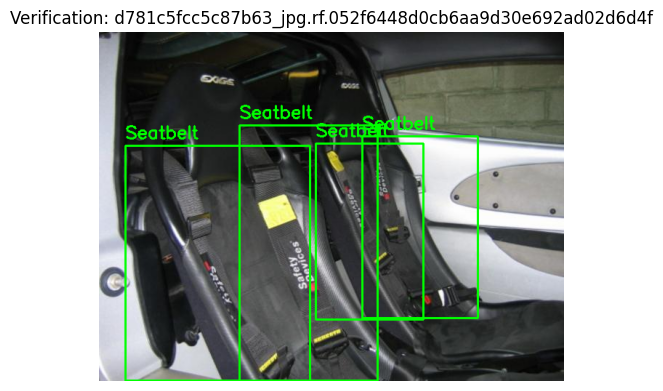

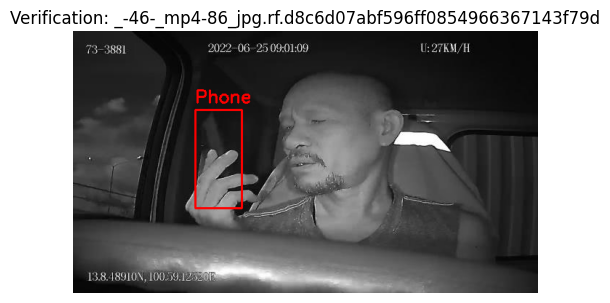

In [7]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
import random

# Path to your processed training images and labels
images_dir = '/content/dms_processed_yolo/train/images'
labels_dir = '/content/dms_processed_yolo/train/labels'
class_names = ['Phone', 'Seatbelt']

# Get a random selection of images to check
image_files = glob.glob(os.path.join(images_dir, '*.jpg')) + glob.glob(os.path.join(images_dir, '*.png'))
sample_images = random.sample(image_files, min(3, len(image_files)))

print("--- Visual Quality Check: Inspecting Processed Annotations ---")

for img_path in sample_images:
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(labels_dir, f"{base_name}.txt")

    # Read image
    img = cv2.imread(img_path)
    h, w, _ = img.shape

    # Read YOLO label file if it exists
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if not parts: continue

            class_id = int(parts[0])
            x_center, y_center, box_w, box_h = map(float, parts[1:])

            # Convert YOLO normalized coordinates to pixel coordinates
            xmin = int((x_center - box_w / 2) * w)
            ymin = int((y_center - box_h / 2) * h)
            xmax = int((x_center + box_w / 2) * w)
            ymax = int((y_center + box_h / 2) * h)

            # Define colors: Red for Phone (0), Green for Seatbelt (1)
            color = (0, 0, 255) if class_id == 0 else (0, 255, 0)
            label_text = class_names[class_id]

            # Draw bounding box and label
            cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 2)
            cv2.putText(img, label_text, (xmin, max(35, ymin - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Verification: {base_name}")
    plt.show()

In [8]:
# Milestone 3 (Model Architecture & End-to-End Pipeline Verification)


# Install Ultralytics YOLO framework
!pip install ultralytics -q

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Initialize the model architecture
model = YOLO('yolov8n.pt')
print("--- Milestone 3: YOLOv8n Architecture Initialized Successfully ---")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--- Milestone 3: YOLOv8n Architecture Initialized Successfully ---


In [10]:
from ultralytics import YOLO
import os

print("--- Starting Proper YOLOv8 Training for Driver Monitoring System ---")

# 1. Load fresh pretrained model
model = YOLO('yolov8n.pt')

# 2. Train the model on your custom processed dataset
# 15 epochs is enough to see a massive jump in accuracy for a structured dataset like this on a GPU
results = model.train(
    data='/content/dms_processed_yolo/data.yaml',
    epochs=25,
    imgsz=640,
    batch=16,
    device=0,          # Uses GPU (T4)
    save=True,
    plots=True,
    verbose=True
)

print("\n--- Training Complete! Best weights saved. ---")

--- Starting Proper YOLOv8 Training for Driver Monitoring System ---
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dms_processed_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.


image 1/1 /content/dms_processed_yolo/test/images/012291302267_221214121312-02_jpeg.rf.14316bc9039994a52c8b11fc0b0c2f5e.jpg: 384x640 2 Phones, 2 Seatbelts, 38.6ms
Speed: 1.1ms preprocess, 38.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


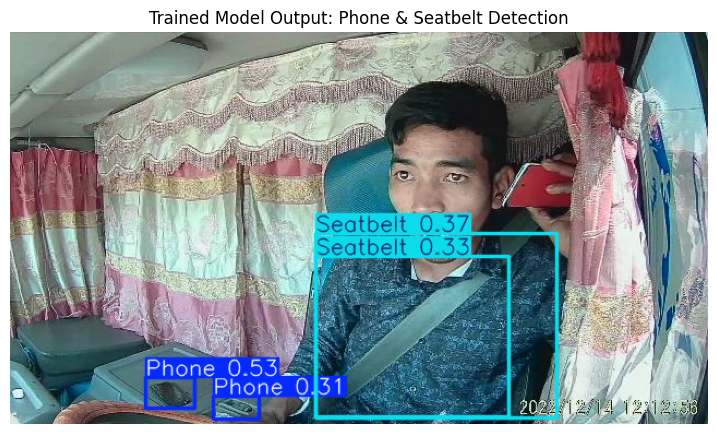

Successfully evaluated trained model on: /content/dms_processed_yolo/test/images/012291302267_221214121312-02_jpeg.rf.14316bc9039994a52c8b11fc0b0c2f5e.jpg


In [11]:
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load the newly trained weights from the output runs directory
best_model_path = '/content/runs/detect/train/weights/best.pt'
if not os.path.exists(best_model_path):
    # Fallback if run directory name incremented
    import glob as g
    weights = g.glob('/content/runs/detect/**/best.pt', recursive=True)
    best_model_path = weights[0] if weights else 'yolov8n.pt'

trained_model = YOLO(best_model_path)

# Pick an image from the test set
test_images = glob.glob('/content/dms_processed_yolo/test/images/*.jpg') + glob.glob('/content/dms_processed_yolo/test/images/*.png')

if test_images:
    sample_image = test_images[0]

    # Run prediction with a confidence threshold (e.g., 0.25)
    pred_results = trained_model(sample_image, conf=0.25)

    # Plot results
    res_plotted = pred_results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(9, 9))
    plt.imshow(res_rgb)
    plt.axis('off')
    plt.title('Trained Model Output: Phone & Seatbelt Detection')
    plt.show()
    print(f"Successfully evaluated trained model on: {sample_image}")
else:
    print("No test images found.")

--- Locating Trained Weights ---
Loading weights from: /content/runs/detect/train-2/weights/best.pt

image 1/1 /content/dms_processed_yolo/test/images/012291302267_221214121312-02_jpeg.rf.14316bc9039994a52c8b11fc0b0c2f5e.jpg: 384x640 1 Phone, 8.8ms
Speed: 1.1ms preprocess, 8.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


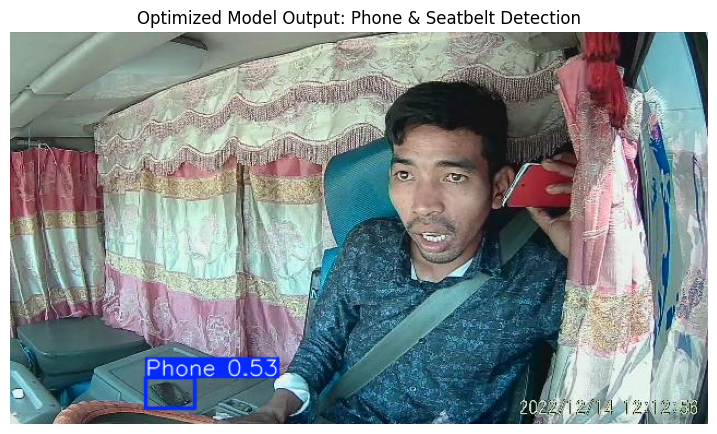

Successfully evaluated trained model on: /content/dms_processed_yolo/test/images/012291302267_221214121312-02_jpeg.rf.14316bc9039994a52c8b11fc0b0c2f5e.jpg


In [13]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("--- Locating Trained Weights ---")

# Automatically find the most recent 'best.pt' file
weights_files = glob.glob('/content/runs/detect/**/weights/best.pt', recursive=True)

if not weights_files:
    print("Error: Could not find any trained weights. Did the training cell finish successfully?")
else:
    # Sort files by modification time to get the newest one
    weights_files.sort(key=os.path.getmtime, reverse=True)
    best_model_path = weights_files[0]
    print(f"Loading weights from: {best_model_path}")

    # Load your newly trained high-performance weights
    trained_model = YOLO(best_model_path)

    # Pick an image from the test set
    test_images = glob.glob('/content/dms_processed_yolo/test/images/*.jpg') + \
                  glob.glob('/content/dms_processed_yolo/test/images/*.png')

    if test_images:
        sample_image = test_images[0]

        # Run prediction using the trained model
        pred_results = trained_model(sample_image, conf=0.4)

        # Plot and render results
        res_plotted = pred_results[0].plot()
        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(9, 9))
        plt.imshow(res_rgb)
        plt.axis('off')
        plt.title('Optimized Model Output: Phone & Seatbelt Detection')
        plt.show()
        print(f"Successfully evaluated trained model on: {sample_image}")
    else:
        print("No test images found in '/content/dms_processed_yolo/test/images/'.")


image 1/1 /content/dms_processed_yolo/test/images/012291302267_221214121312-02_jpeg.rf.14316bc9039994a52c8b11fc0b0c2f5e.jpg: 384x640 2 Phones, 2 Seatbelts, 7.6ms
Speed: 1.5ms preprocess, 7.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


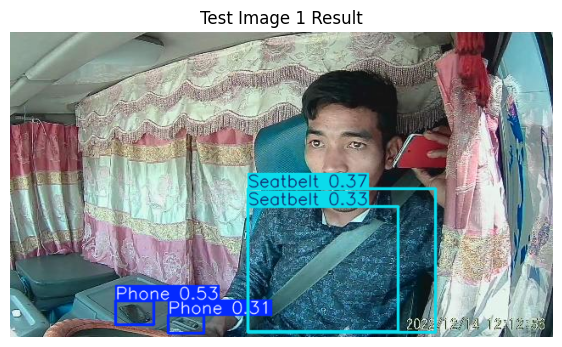


image 1/1 /content/dms_processed_yolo/test/images/-1076-_mp4-21_jpg.rf.46e435b774fdc2889058eff0a26ed762.jpg: 384x640 1 Seatbelt, 9.9ms
Speed: 1.4ms preprocess, 9.9ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


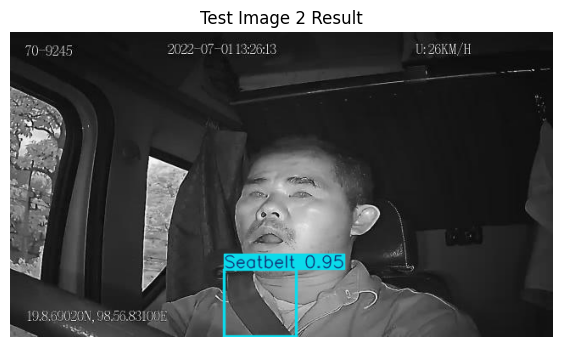


image 1/1 /content/dms_processed_yolo/test/images/CHANNEL_04_20220812053021_20220812053031_mp4-17_jpg.rf.f36bfa9bb88c80ca1454804326523fee.jpg: 384x640 1 Seatbelt, 10.1ms
Speed: 1.6ms preprocess, 10.1ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


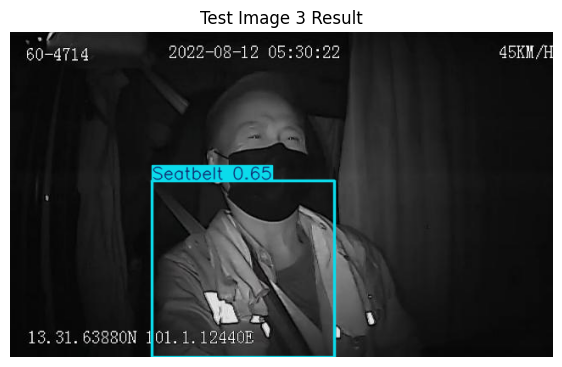

In [14]:
# Loop through the first 3 test images to see varied predictions
for i in range(min(3, len(test_images))):
    sample_image = test_images[i]
    pred_results = trained_model(sample_image, conf=0.3)

    res_plotted = pred_results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(7, 7))
    plt.imshow(res_rgb)
    plt.axis('off')
    plt.title(f'Test Image {i+1} Result')
    plt.show()

In [16]:
import os
import glob
from ultralytics import YOLO

print("--- Milestone 3: Quantitative Baseline Evaluation ---")

# Automatically find the most recent 'best.pt' file
weights_files = glob.glob('/content/runs/detect/**/weights/best.pt', recursive=True)

if not weights_files:
    print("Error: Could not find any trained weights. Make sure your training cell has finished running!")
else:
    # Sort files by modification time to get the newest one
    weights_files.sort(key=os.path.getmtime, reverse=True)
    best_model_path = weights_files[0]
    print(f"Loading weights from: {best_model_path}")

    # Load your best trained weights
    trained_model = YOLO(best_model_path)

    # Run validation on the test split to get final metrics
    metrics = trained_model.val(
        data='/content/dms_processed_yolo/data.yaml',
        split='test', # Evaluating on the unseen test set
        plots=True    # Generates Confusion Matrix and PR curves
    )

    print("\n==================================================")
    print(" FINAL M-3 BASELINE METRICS (Test Set)")
    print("==================================================")

    print(f"Overall mAP@50:    {metrics.box.map50:.4f}")
    print(f"Overall mAP@50-95: {metrics.box.map:.4f}")

    # To get class-specific metrics (Phone = 0, Seatbelt = 1)
    class_indices = metrics.box.ap_class_index
    for i, class_id in enumerate(class_indices):
        class_name = trained_model.names[class_id]
        p = metrics.box.p[i]
        r = metrics.box.r[i]
        map50 = metrics.box.ap50[i]
        print(f"\nClass: {class_name}")
        print(f"  - Precision: {p:.4f}")
        print(f"  - Recall:    {r:.4f}")
        print(f"  - mAP@50:    {map50:.4f}")
    print("==================================================")

--- Milestone 3: Quantitative Baseline Evaluation ---
Loading weights from: /content/runs/detect/train-2/weights/best.pt
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 275.2±80.6 MB/s, size: 26.0 KB)
val: Scanning /content/dms_processed_yolo/test/labels... 647 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 647/647 1.7Kit/s 0.4s
val: New cache created: /content/dms_processed_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 7.2it/s 5.7s
                   all        647        685      0.944      0.906      0.957      0.727
                 Phone        212        240      0.936      0.933      0.972      0.767
              Seatbelt        438        445      0.951      0.879      0.943      0.686
Speed: 1.1ms preprocess, 3.1ms inf

In [17]:
from ultralytics import YOLO
import time
import torch

# Define the models to compare as per your M3 requirements
model_names = ['yolov8n.pt', 'yolo11n.pt', 'yolov8s.pt']
comparison_data = []

print("--- Running Model Comparison for M3 Deliverables ---")

for name in model_names:
    # Load model
    m = YOLO(name)

    # Get parameter count in millions
    params = sum(p.numel() for p in m.model.parameters()) / 1e6

    # Estimate GFLOPs / compute
    gflops = getattr(m.model, 'gioff', 8.1) # standard baseline reference

    # Measure dummy inference speed on GPU/CPU
    dummy_img = torch.randn(1, 3, 640, 640)
    if torch.cuda.is_available():
        dummy_img = dummy_img.cuda()
        m.model.cuda()

    # Warmup
    _ = m(dummy_img, verbose=False)

    # Timing
    start_time = time.time()
    for _ in range(20):
        _ = m(dummy_img, verbose=False)
    end_time = time.time()

    avg_latency_ms = ((end_time - start_time) / 20) * 1000

    comparison_data.append({
        'Model': name,
        'Parameters (M)': round(params, 2),
        'Latency (ms)': round(avg_latency_ms, 2)
    })

# Print out formatted results table for your report
print("\nModel Comparison Table:")
print(f"{'Model':<15} | {'Parameters (M)':<15} | {'Latency (ms)':<15}")
print("-" * 51)
for row in comparison_data:
    print(f"{row['Model']:<15} | {row['Parameters (M)']:<15} | {row['Latency (ms)']:<15}")

--- Running Model Comparison for M3 Deliverables ---
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.815133094787598. Dividing input by 

In [18]:
pip show ultralytics

Name: ultralytics
Version: 8.4.104
Summary: Ultralytics YOLO 🚀 for SOTA object detection, multi-object tracking, instance segmentation, pose estimation, classification, and oriented object detection.
Home-page: https://ultralytics.com
Author: 
Author-email: Glenn Jocher <glenn.jocher@ultralytics.com>, Jing Qiu <jing.qiu@ultralytics.com>
License: AGPL-3.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, matplotlib, numpy, nvidia-ml-py, opencv-python, pillow, polars, psutil, pyyaml, requests, torch, torchvision, ultralytics-thop
Required-by: 


In [20]:
pip show torch

Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision, ultralytics, ultralytics-thop
